# Autoencoder Experiments - Single Run Per Model

This notebook runs one full training + analysis workflow for each model.


In [1]:
from autoencoder_workflow import AutoencoderWorkflow


In [2]:
# Common config
DATA_DIR = '/home/marmatt/Documents/projects/BRAF/myWork/workflowJanuary2026/Results/activation_segments/fitted_mda/'
BASE_OUTPUT_DIR = 'Results/run_trial_BRAFActivationLoop_postalign_checkpoint0'
ATOM_SELECTION = ['CA']
MAX_EPOCHS = 32
PATIENCE = 32


## Small Autoencoder (Single Run)


In [3]:
wf_small = AutoencoderWorkflow(
    folder_name=DATA_DIR,
    output_base_dir=BASE_OUTPUT_DIR,
    manual_seed=25,
    batch_size=8,
)
wf_small.prepare_data(atom_selection=ATOM_SELECTION)
wf_small.set_output_subfolder('small_single_run', create=True)
wf_small.train(max_epochs=MAX_EPOCHS, patience=PATIENCE)


Dataset shape: torch.Size([2523, 27, 3])
mean: 110.1438756714563
 std: 20.30379482405781
Loaded 2523 structures
[output] model=Small_AutoEncoder output=Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/small_single_run
device: cuda
[train] model=Small_AutoEncoder output=Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/small_single_run
epoch              : 0
train_mse_loss     : 0.114768
train_loss         : 0.114768
valid_mse_loss     : 0.028512
valid_loss         : 0.028512
train_seconds      : 1.499665
valid_seconds      : 0.060877
checkpoint_seconds : 0.099983
total_seconds      : 1.660526

epoch              : 1
train_mse_loss     : 0.025723
train_loss         : 0.025723
valid_mse_loss     : 0.018440
valid_loss         : 0.018440
train_seconds      : 1.144718
valid_seconds      : 0.052900
checkpoint_seconds : 0.106461
total_seconds      : 1.304079

epoch              : 2
train_mse_loss     : 0.018747
train_loss         : 0.018747
valid_mse_loss     : 0.014906
val

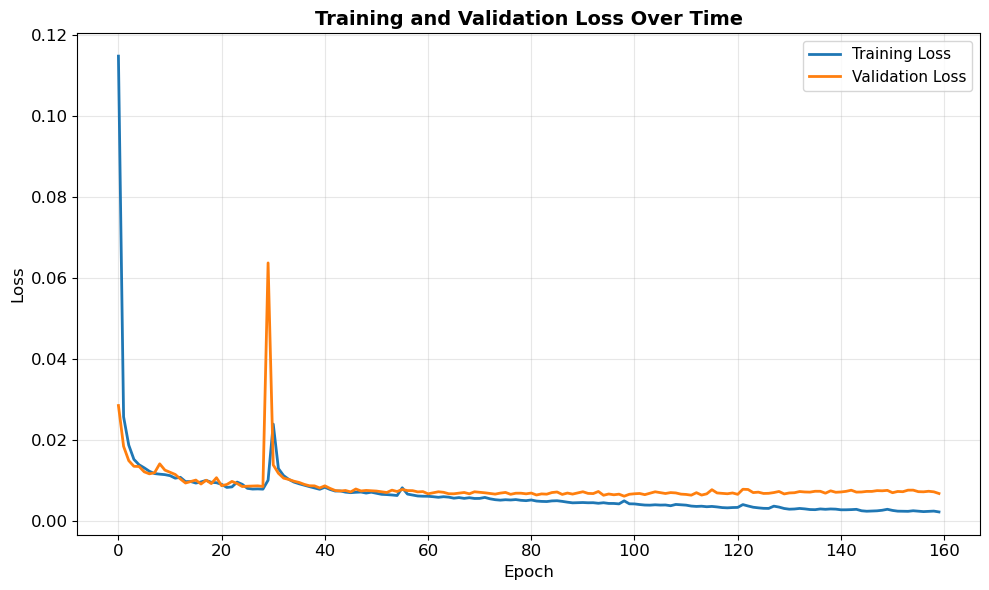

Final training loss: 0.002243
Final validation loss: 0.006791
Best validation loss: 0.006127 (epoch 98)


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Training and Validation Loss Over Time'}, xlabel='Epoch', ylabel='Loss'>,
      train_mse_loss  train_loss  valid_mse_loss  valid_loss  epoch  \
 0          0.114768    0.114768        0.028512    0.028512      0   
 1          0.025723    0.025723        0.018440    0.018440      1   
 2          0.018747    0.018747        0.014906    0.014906      2   
 3          0.015216    0.015216        0.013505    0.013505      3   
 4          0.013887    0.013887        0.013457    0.013457      4   
 ..              ...         ...             ...         ...    ...   
 155        0.002437    0.002437        0.007246    0.007246    155   
 156        0.002323    0.002323        0.007209    0.007209    156   
 157        0.002372    0.002372        0.007346    0.007346    157   
 158        0.002448    0.002448        0.007209    0.007209    158   
 159        0.002243    0.002243        0.006791    0.006791    159   
 
      tra

In [4]:
wf_small.plot_training_history(log_filename='log.dat')

In [5]:
# Setup and run analysis
wf_small.setup_analysis(atom_selection=ATOM_SELECTION)
wf_small.extract_dataset()
wf_small.decode_structures()
wf_small.calculate_errors(save_prefix='_small_checkpoint')
wf_small.scan_error_landscape(grid_size=30, save_prefix='_small_checkpoint')
wf_small.extract_encoded_coordinates(save_prefix='_small_checkpoint')


[analysis] model=Small_AutoEncoder output=Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/small_single_run


encoding training: 284it [00:00, 1311.54it/s]
Generating pdb files: 100%|██████████| 2271/2271 [00:01<00:00, 1491.44it/s]
encoding validation: 32it [00:00, 1323.82it/s]
Generating pdb files: 100%|██████████| 252/252 [00:00<00:00, 1757.09it/s]
Decoding training: 284it [00:00, 1219.59it/s]
Decoding validation: 32it [00:00, 1157.14it/s]
Decoding grid: 113it [00:00, 1270.88it/s]
encoding grid_decoded: 113it [00:00, 1297.88it/s]
Decoding grid_decoded: 113it [00:00, 1372.43it/s]


Saved error violin plot to Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/small_single_run/ErrorViolinsTrainVsValid_small.png


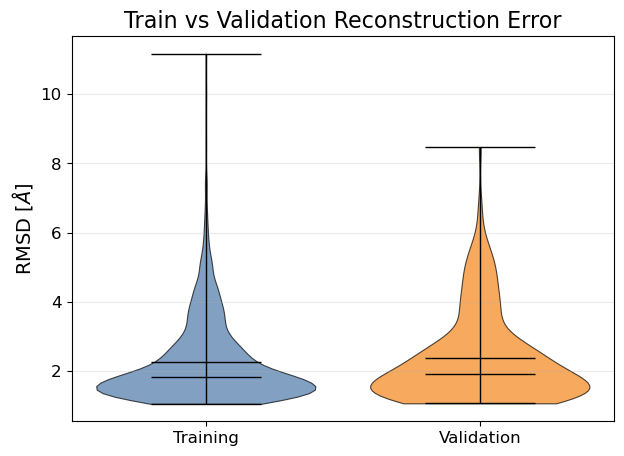

Saved RMSD landscape projection to Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/small_single_run/RMSDlandscapesOnePlot_small.png


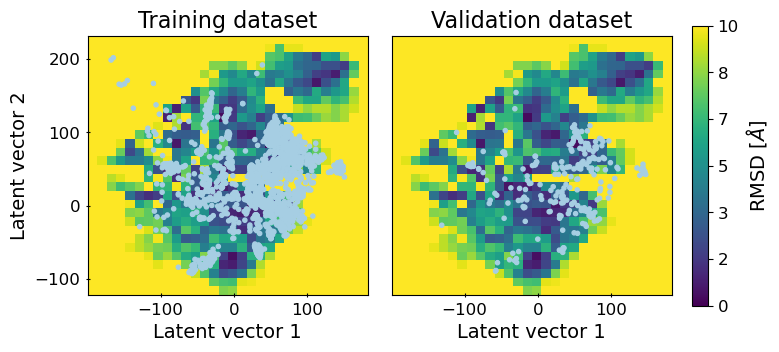

(<Figure size 800x800 with 3 Axes>,
 (<Axes: title={'center': 'Training dataset'}, xlabel='Latent vector 1', ylabel='Latent vector 2'>,
  <Axes: title={'center': 'Validation dataset'}, xlabel='Latent vector 1'>))

In [ ]:
# Classic one-run visualizations
wf_small.plot_error_violins(output_file='ErrorViolinsTrainVsValid_small.png', save_prefix='_small_checkpoint')
wf_small.plot_rmsd_landscape_projection(output_file='RMSDlandscapesOnePlot_small.png', save_prefix='_small_checkpoint')

TypeError: unsupported operand type(s) for -: 'NoneType' and 'NoneType'

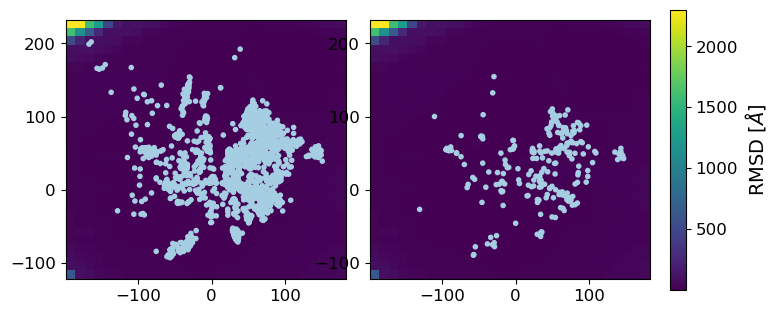

## 2D CNN Autoencoder (Single Run)


In [7]:
wf_cnn2d = AutoencoderWorkflow(
    folder_name=DATA_DIR,
    output_base_dir=BASE_OUTPUT_DIR,
    manual_seed=25,
    batch_size=8,
)
wf_cnn2d.prepare_data(atom_selection=ATOM_SELECTION)
wf_cnn2d.train_cnn2d_ae(
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    latent_dim=2,
    output_subfolder='cnn2d_single_run',
)


Dataset shape: torch.Size([2523, 27, 3])
mean: 110.1438756714563
 std: 20.30379482405781
Loaded 2523 structures
[output] model=Small_AutoEncoder output=Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/cnn2d_single_run
device: cuda
VAE: dims=[27, 13, 6], channels=[1, 32, 64]
[train] model=AutoEncoder output=Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/cnn2d_single_run
epoch              : 0
train_mse_loss     : 0.142655
train_loss         : 0.142655
valid_mse_loss     : 0.016547
valid_loss         : 0.016547
train_seconds      : 0.349878
valid_seconds      : 0.015722
checkpoint_seconds : 0.002915
total_seconds      : 0.368515

epoch              : 1
train_mse_loss     : 0.016379
train_loss         : 0.016379
valid_mse_loss     : 0.014100
valid_loss         : 0.014100
train_seconds      : 0.306051
valid_seconds      : 0.013898
checkpoint_seconds : 0.002932
total_seconds      : 0.322882

epoch              : 2
train_mse_loss     : 0.014479
train_loss         : 0.01

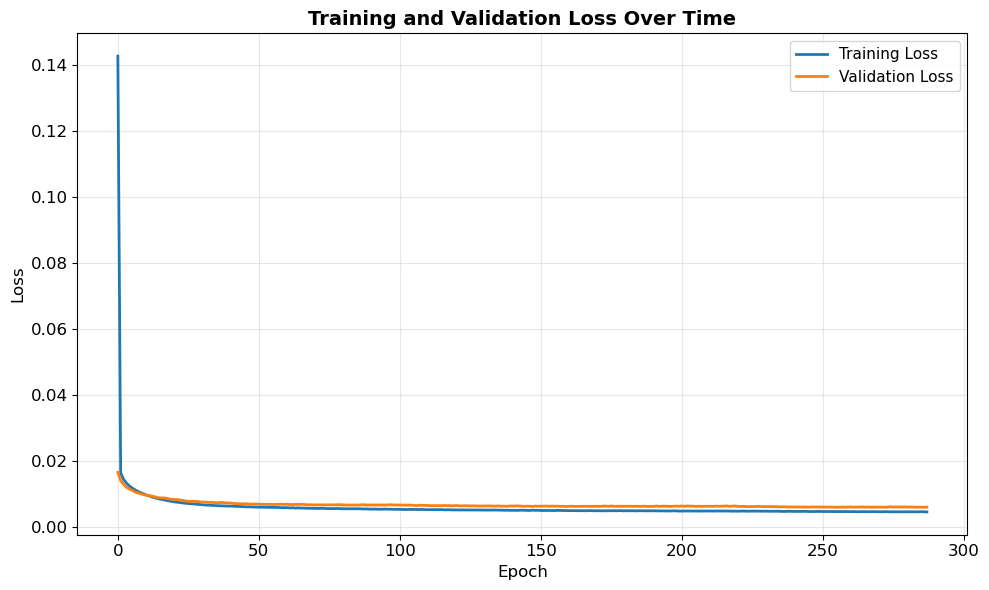

Final training loss: 0.004573
Final validation loss: 0.006021
Best validation loss: 0.005966 (epoch 255)


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Training and Validation Loss Over Time'}, xlabel='Epoch', ylabel='Loss'>,
      train_mse_loss  train_loss  valid_mse_loss  valid_loss  epoch  \
 0          0.142655    0.142655        0.016547    0.016547      0   
 1          0.016379    0.016379        0.014100    0.014100      1   
 2          0.014479    0.014479        0.012969    0.012969      2   
 3          0.013362    0.013362        0.012087    0.012087      3   
 4          0.012523    0.012523        0.011553    0.011553      4   
 ..              ...         ...             ...         ...    ...   
 283        0.004575    0.004575        0.006005    0.006005    283   
 284        0.004605    0.004605        0.006022    0.006022    284   
 285        0.004646    0.004646        0.006013    0.006013    285   
 286        0.004615    0.004615        0.005971    0.005971    286   
 287        0.004573    0.004573        0.006021    0.006021    287   
 
      tra

In [8]:
wf_cnn2d.plot_training_history(log_filename='log.dat')

In [9]:
# Setup and run analysis
wf_cnn2d.setup_analysis(atom_selection=ATOM_SELECTION)
wf_cnn2d.extract_dataset()
wf_cnn2d.decode_structures()
wf_cnn2d.calculate_errors(save_prefix='_cnn2d_checkpoint')
wf_cnn2d.scan_error_landscape(grid_size=30, save_prefix='_cnn2d_checkpoint')
wf_cnn2d.extract_encoded_coordinates(save_prefix='_cnn2d_checkpoint')


[analysis] model=AutoEncoder output=Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/cnn2d_single_run


encoding training: 284it [00:00, 4368.19it/s]
Generating pdb files: 100%|██████████| 2271/2271 [00:01<00:00, 1696.84it/s]
encoding validation: 32it [00:00, 3797.47it/s]
Generating pdb files: 100%|██████████| 252/252 [00:00<00:00, 1753.92it/s]
Decoding training: 284it [00:00, 7103.39it/s]
Decoding validation: 32it [00:00, 6436.07it/s]
Decoding grid: 113it [00:00, 6962.37it/s]
encoding grid_decoded: 113it [00:00, 3783.18it/s]
Decoding grid_decoded: 113it [00:00, 7744.51it/s]


Saved error violin plot to Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/cnn2d_single_run/ErrorViolinsTrainVsValid_cnn2d.png


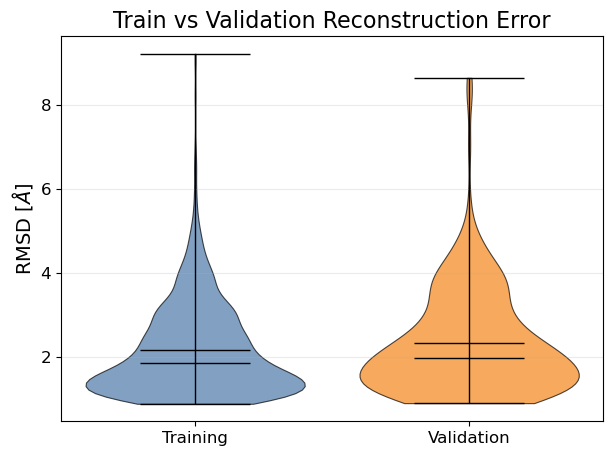

Saved RMSD landscape projection to Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/cnn2d_single_run/RMSDlandscapesOnePlot_cnn2d.png


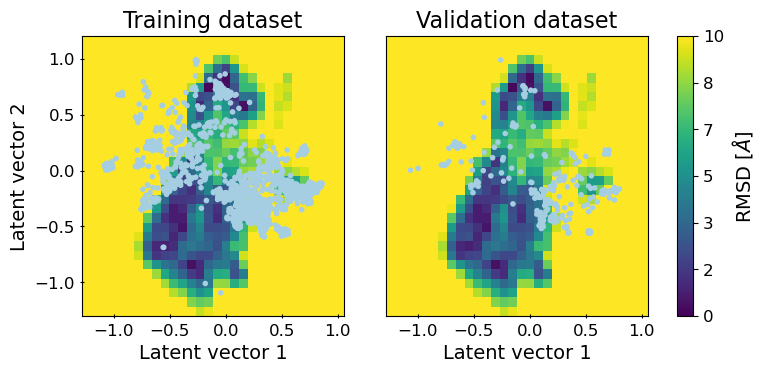

(<Figure size 800x800 with 3 Axes>,
 (<Axes: title={'center': 'Training dataset'}, xlabel='Latent vector 1', ylabel='Latent vector 2'>,
  <Axes: title={'center': 'Validation dataset'}, xlabel='Latent vector 1'>))

In [10]:
# Classic one-run visualizations
wf_cnn2d.plot_error_violins(output_file='ErrorViolinsTrainVsValid_cnn2d.png', save_prefix='_cnn2d_checkpoint')
wf_cnn2d.plot_rmsd_landscape_projection(output_file='RMSDlandscapesOnePlot_cnn2d.png', save_prefix='_cnn2d_checkpoint')

## Writhe - 2D CNN Autoencoder (Single Run)
